In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

df = pd.read_csv('../data/cleaned/city_day_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])
print("✅ Data loaded")

✅ Data loaded


In [2]:
# Use the most polluted city for forecasting demo
city_name = 'Ahmedabad'
city_df = df[df['City'] == city_name].sort_values('Date').reset_index(drop=True)
city_df = city_df[['Date', 'AQI']].dropna()

print("City data shape:", city_df.shape)
city_df.head()

City data shape: (1334, 2)


,Date,AQI
0,2015-01-29,209.0
1,2015-01-30,328.0
2,2015-01-31,514.0
3,2015-02-01,782.0
4,2015-02-02,914.0


In [3]:
scaler = MinMaxScaler(feature_range=(0,1))
aqi_scaled = scaler.fit_transform(city_df[['AQI']])
print("✅ Scaled AQI shape:", aqi_scaled.shape)

✅ Scaled AQI shape: (1334, 1)


In [4]:
def create_sequences(data, window=7):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW = 7
X, y = create_sequences(aqi_scaled, WINDOW)

# Reshape for LSTM: [samples, timesteps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (1327, 7, 1) y shape: (1327,)


In [5]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1061, 7, 1) Test: (266, 7, 1)


In [6]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

d:\Projects\aqi-predictor-project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0242 - val_loss: 0.0129
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0190 - val_loss: 0.0123
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0183 - val_loss: 0.0133
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0180 - val_loss: 0.0126
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0175 - val_loss: 0.0121
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0173 - val_loss: 0.0102
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0165 - val_loss: 0.0094
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0158 - val_loss: 0.0090
Epoch 9/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0157 - val_loss: 0.0100
Epoch 10/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0145 - val_loss: 0.0085
Epoch 11/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0143 - val_loss: 0.0089
Epoch 12/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0142 - val_

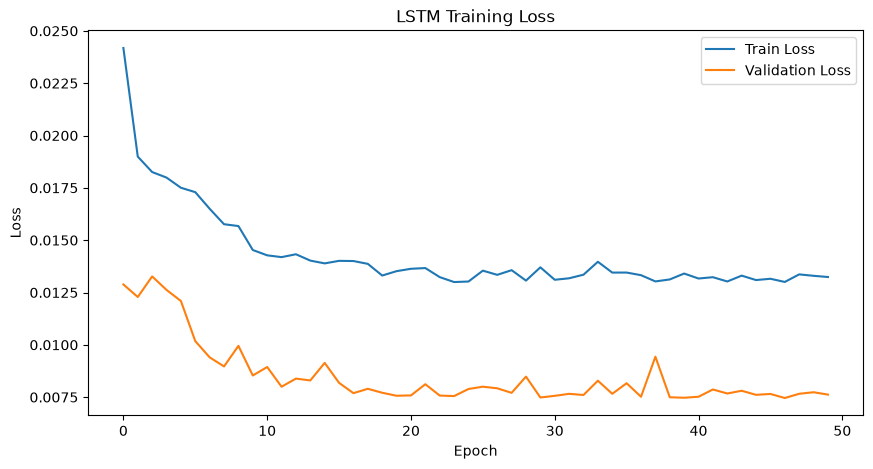

In [8]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.savefig('../reports/09_lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

# Inverse transform back to actual AQI values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_actual = scaler.inverse_transform(y_pred)

mae_lstm = mean_absolute_error(y_test_actual, y_pred_actual)
r2_lstm = r2_score(y_test_actual, y_pred_actual)

print(f"LSTM MAE: {mae_lstm:.2f}")
print(f"LSTM R²:  {r2_lstm:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
LSTM MAE: 123.12
LSTM R²:  0.5901


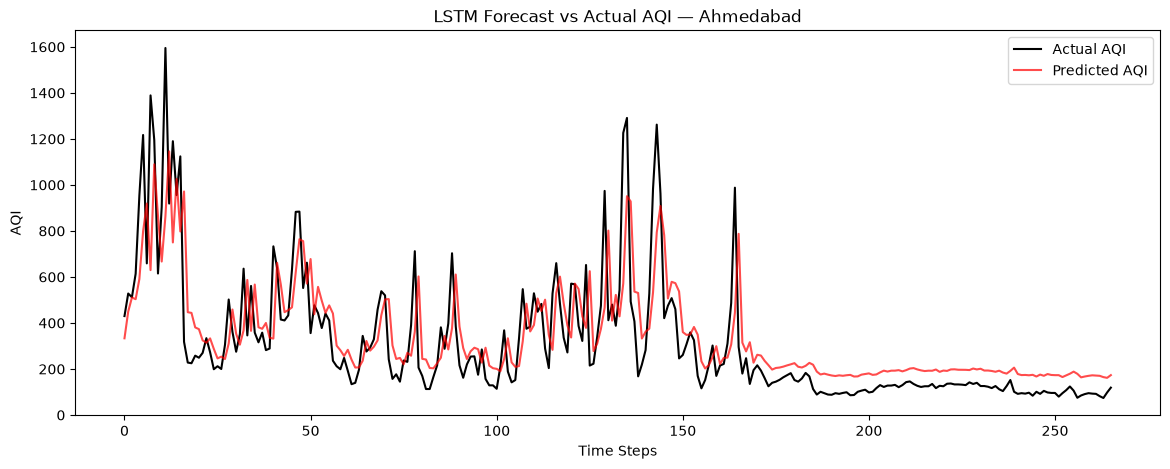

In [10]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual AQI', color='black')
plt.plot(y_pred_actual, label='Predicted AQI', color='red', alpha=0.7)
plt.title(f'LSTM Forecast vs Actual AQI — {city_name}')
plt.xlabel('Time Steps'); plt.ylabel('AQI')
plt.legend()
plt.savefig('../reports/10_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
model.save('../models/aqi_lstm_model.h5')
import joblib
joblib.dump(scaler, '../models/lstm_scaler.pkl')
print("✅ LSTM model and scaler saved")

✅ LSTM model and scaler saved
